In [1]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.1/91.1 kB 4.4 MB/s eta 0:00:00


In [4]:
from google.colab import files

uploaded = files.upload()

Saving Screenshot 2026-09-29 143624.png to Screenshot 2026-09-29 143624.png


In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Get the uploaded filename automatically
filename = next(iter(uploaded))

# Read the image
image = cv2.imread(filename)

if image is None:
    raise FileNotFoundError("Image could not be loaded")

print("Image loaded successfully!")
print("Filename:", filename)
print("Image size:", image.shape)

Image loaded successfully!
Filename: Screenshot 2026-09-29 143624.png
Image size: (413, 636, 3)


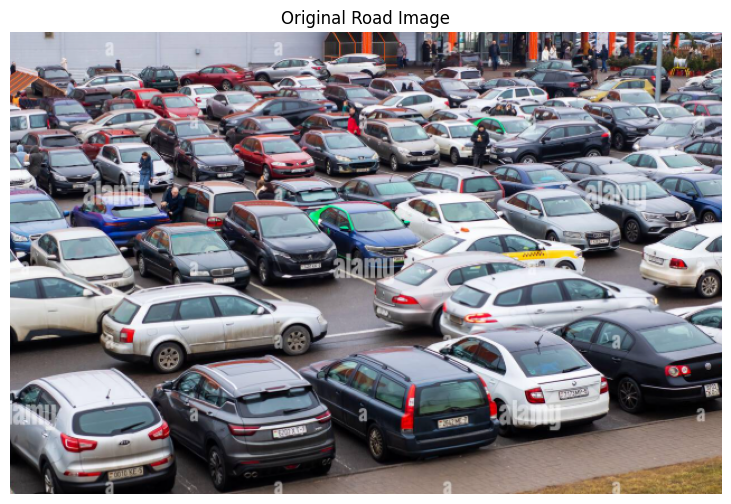

In [9]:
plt.figure(figsize=(10, 6))

# Convert BGR to RGB for displaying
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image_rgb)
plt.title("Original Road Image")
plt.axis("off")
plt.show()

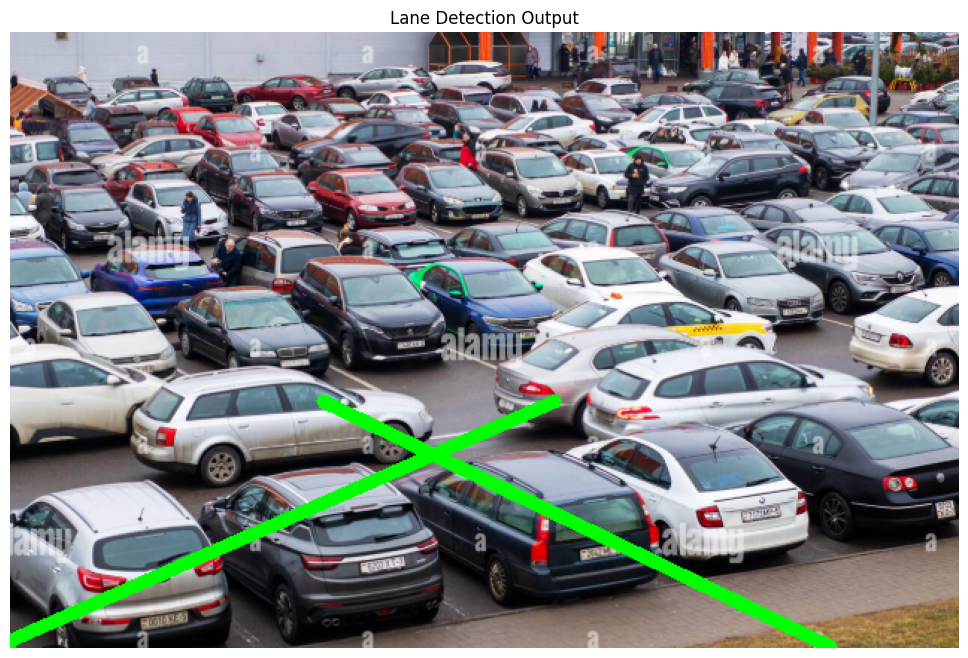

In [10]:
# Make a copy of the original image
output = image.copy()

# -----------------------------------
# 1. Convert image to grayscale
# -----------------------------------

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)


# -----------------------------------
# 2. Apply Gaussian Blur
# -----------------------------------

blur = cv2.GaussianBlur(gray, (5, 5), 0)


# -----------------------------------
# 3. Detect edges using Canny
# -----------------------------------

edges = cv2.Canny(blur, 50, 150)


# -----------------------------------
# 4. Create Region of Interest (ROI)
# -----------------------------------

h, w = edges.shape

mask = np.zeros_like(edges)

polygon = np.array([[
    (0, h),
    (w, h),
    (int(0.58 * w), int(0.58 * h)),
    (int(0.42 * w), int(0.58 * h))
]], dtype=np.int32)

cv2.fillPoly(mask, polygon, 255)

roi_edges = cv2.bitwise_and(edges, mask)


# -----------------------------------
# 5. Hough Transform
# -----------------------------------

lines = cv2.HoughLinesP(
    roi_edges,
    rho=1,
    theta=np.pi / 180,
    threshold=30,
    minLineLength=30,
    maxLineGap=100
)


# -----------------------------------
# 6. Separate left and right lanes
# -----------------------------------

left_lines = []
right_lines = []

if lines is not None:

    # Convert to [x1, y1, x2, y2]
    lines = lines.reshape(-1, 4)

    for x1, y1, x2, y2 in lines:

        # Avoid division by zero
        if x2 == x1:
            continue

        # Calculate slope
        slope = (y2 - y1) / (x2 - x1)

        # Negative slope = left lane
        if -1.5 < slope < -0.4:
            left_lines.append((x1, y1, x2, y2))

        # Positive slope = right lane
        elif 0.4 < slope < 1.5:
            right_lines.append((x1, y1, x2, y2))


# -----------------------------------
# 7. Average detected lines
# -----------------------------------

def average_line(lines, y_bottom, y_top):

    if len(lines) == 0:
        return None

    xs = []
    ys = []

    for x1, y1, x2, y2 in lines:

        xs.extend([x1, x2])
        ys.extend([y1, y2])

    # Fit line: y = slope*x + intercept
    slope, intercept = np.polyfit(xs, ys, 1)

    if abs(slope) < 1e-6:
        return None

    # Calculate x positions
    x_bottom = int((y_bottom - intercept) / slope)
    x_top = int((y_top - intercept) / slope)

    return x_bottom, y_bottom, x_top, y_top


# -----------------------------------
# 8. Calculate lane positions
# -----------------------------------

y_bottom = h - 1
y_top = int(0.60 * h)

left_lane = average_line(
    left_lines,
    y_bottom,
    y_top
)

right_lane = average_line(
    right_lines,
    y_bottom,
    y_top
)


# -----------------------------------
# 9. Draw left lane
# -----------------------------------

if left_lane is not None:

    x1, y1, x2, y2 = left_lane

    cv2.line(
        output,
        (x1, y1),
        (x2, y2),
        (0, 255, 0),
        8
    )


# -----------------------------------
# 10. Draw right lane
# -----------------------------------

if right_lane is not None:

    x1, y1, x2, y2 = right_lane

    cv2.line(
        output,
        (x1, y1),
        (x2, y2),
        (0, 255, 0),
        8
    )


# -----------------------------------
# 11. Display final result
# -----------------------------------

output_rgb = cv2.cvtColor(
    output,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(14, 8))

plt.imshow(output_rgb)

plt.title("Lane Detection Output")

plt.axis("off")

plt.show()